Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


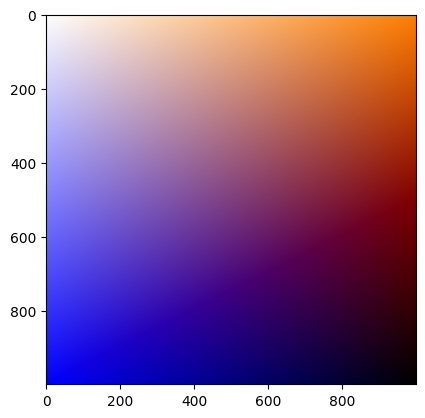

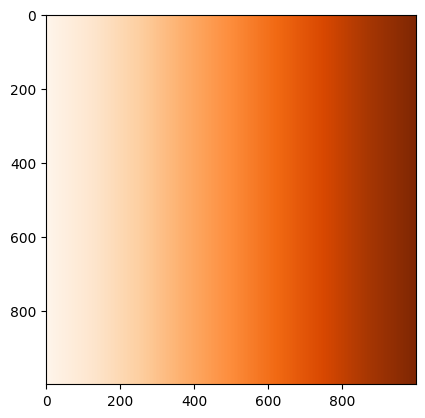

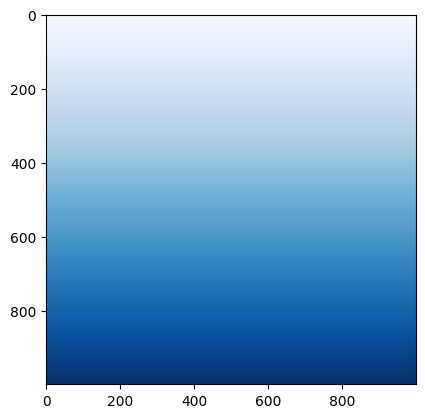

In [45]:

import numpy as np
import matplotlib.pyplot as plt

def colorbar_for_tim():

    def blend_arrays(array0, array1, xmin, xmax):

        array0, array1 = np.log10(array0), np.log10(array1)
        
        # Normalize arrays between 0 and 1
        a0 = (array0 - xmin) / (xmax - xmin)
        a1 = (array1 - xmin) / (xmax - xmin)
        a0[np.isnan(a0)] = 0
        a1[np.isnan(a1)] = 0 
        a0[a0 > 1] = 1
        a1[a1 > 1] = 1 
        a0[a0 < 0] = 0
        a1[a1 < 0] = 0 

        # Create RGB image: R from array1, B from array0, G optional
        rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        rgb[..., 0] -= a0   # Red channel = array1
        rgb[..., 1] -= (a0 + a1*0.5)   # Green channel = array1
        rgb[..., 2] -= a1   # Blue channel = array0

        return rgb

    nx, ny = 1000, 1000
    vmin, vmax = np.log10(1/24), np.log10(365.25*1.4)
    max_inundation_duration = np.tile(10**np.linspace(vmin, vmax, nx), reps = ny).reshape(ny,nx).T
    max_emergent_duration = np.tile(10**np.linspace(vmin, vmax, ny), reps = nx).reshape(nx,ny)

    rgb_code = blend_arrays(max_inundation_duration, max_emergent_duration, vmin, vmax)

    return max_inundation_duration, max_emergent_duration, rgb_code

max_inundation_duration, max_emergent_duration, rgb_code = colorbar_for_tim()

plt.imshow(rgb_code)
plt.show()

plt.imshow(np.log10(max_emergent_duration), cmap = 'Oranges')
plt.show()
plt.imshow(np.log10(max_inundation_duration), cmap = 'Blues')
plt.show()